# Company A — Turning Churn Data into Protected Revenue
### A Proof-of-Concept retention engine for a US wireless carrier

**Author:** Hazem Douzi  |  **Submission:** Final Assignment

This notebook is the reproducible technical backbone of the accompanying slide deck. It runs
**end-to-end** (`Kernel → Restart & Run All`, or `jupyter nbconvert --execute`) and reproduces every
metric and figure cited in the deck.

**Storyline**
1. Market analysis — a saturated US wireless market where retention beats acquisition 5–10×.
2. EDA — churn here is a *behavioral/equipment* problem, not a demographic one.
3. Problem definition — predict 30–60 day voluntary churn; rank by **Expected Value at Risk (EVaR)**.
4. Models — Logistic Regression, Random Forest, XGBoost, LightGBM (ROC-AUC, lift, capture).
5. Value-based targeting + actionable personas.
6. Business case — quantified revenue protected, avoided reacquisition cost, ROI and sensitivity.

> *Data:* `telecom/Client.csv` (customer & equipment attributes) merged with `telecom/Record.csv`
> (usage, billing, call-quality, and the `churn` target) on `Customer_ID` — 100,000 customers × 100 columns.


## 0. Setup

In [1]:
import warnings, json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RNG = 42
np.random.seed(RNG)
plt.rcParams.update({"figure.dpi": 110, "font.size": 12, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
NAVY, RED, TEAL, AMBER, GREY = "#1f3b73", "#d1495b", "#15919b", "#e9a000", "#9aa3ad"
print("Environment ready.")

Environment ready.


## 1. Load & merge the two source tables

In [2]:
# Robust path resolution so the notebook runs from repo root or the solution/ folder
CANDIDATES = ["telecom", "solution/telecom", "../telecom",
              "05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom"]
DATA = next((p for p in CANDIDATES if os.path.exists(os.path.join(p, "Client.csv"))), "telecom")
print("Using data directory:", DATA)

client = pd.read_csv(f"{DATA}/Client.csv")
record = pd.read_csv(f"{DATA}/Record.csv")
df = record.merge(client, on="Customer_ID", how="inner")
print("Client:", client.shape, "| Record:", record.shape, "| Merged:", df.shape)
df.head(3)

Using data directory: telecom


Client: (100000, 50) | Record: (100000, 51) | Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0


## 2. Market analysis (external context)

The data describes a **US wireless carrier** (regions such as *Chicago*, *Los Angeles*, *New York City*).
We anchor the business case in the current market:

| Fact | Value | Source |
|---|---|---|
| US wireless services revenue (2024) | **\$215–321 B** | MarketLine [1]; IBISWorld [2] |
| Total subscriptions | **632 M** | MarketLine [1] |
| Market growth (CAGR ’19–’24) | **~2.4%** → saturated, share-of-wallet game | MarketLine [1] |
| Postpaid phone churn (Q4 2024) | **0.86–0.92% / month** | T-Mobile [3]; Verizon [4] |
| Cost to acquire vs retain | **5–10× more to acquire** | SAS/HBR [5]; Simon-Kucher [6] |
| +5% retention → profit uplift | **+25–95%** | Bain & Co. [5] |
| Avg revenue per line (ARPU) | **~\$45–60** (Verizon ARPA \$139.77/account) | Verizon [4] |
| Cost per gross add (CAC) | **~\$350–400** | Investopedia/CPGA [7] |

**Implication.** In a saturated market with ~2% monthly churn (~22%/yr attrition [5]), growth must come from
**keeping** profitable customers. A single percentage point of churn avoided is worth far more than the same
spend on acquisition. That is the wedge this PoC exploits.


## 3. Exploratory Data Analysis

Churn balance:
churn
0    50438
1    49562
Name: count, dtype: int64 

Churn rate in modeling sample: 49.6%  (oversampled/balanced — real-world ~2%/mo)


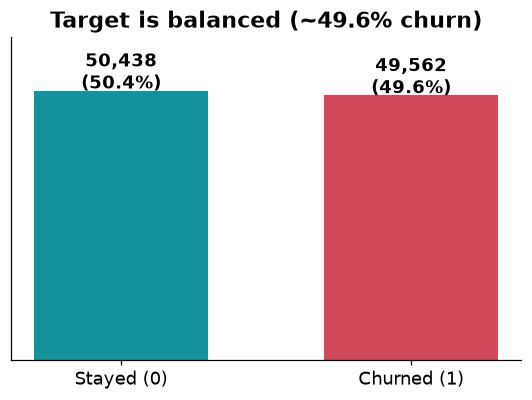

In [3]:
y = df["churn"].astype(int)
print("Churn balance:")
print(y.value_counts(), "\n")
print(f"Churn rate in modeling sample: {y.mean():.1%}  (oversampled/balanced — real-world ~2%/mo)")

fig, ax = plt.subplots(figsize=(5,3.8))
vc = y.value_counts().sort_index()
ax.bar(["Stayed (0)","Churned (1)"], vc.values, color=[TEAL,RED], width=0.6)
for i,v in enumerate(vc.values): ax.text(i, v+400, f"{v:,}\n({v/len(y):.1%})", ha="center", fontweight="bold")
ax.set_title("Target is balanced (~49.6% churn)"); ax.set_yticks([]); ax.set_ylim(0,vc.max()*1.2)
plt.tight_layout(); plt.show()

### 3.1 Data quality — which signals can we trust?

Before modeling we check missingness, because *unreliable inputs cannot drive a business decision.*

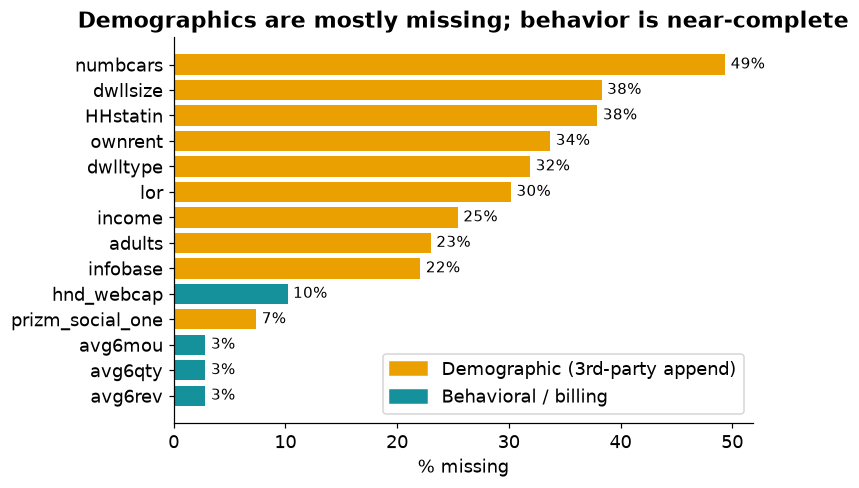

In [4]:
miss = (df.isna().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0.5].head(14)[::-1]
demo = {"numbcars","dwllsize","HHstatin","ownrent","dwlltype","lor","income","adults",
        "infobase","marital","creditcd","ethnic","forgntvl","prizm_social_one"}
colors = [AMBER if c in demo else TEAL for c in miss.index]
fig, ax = plt.subplots(figsize=(7.2,4.6))
ax.barh(miss.index, miss.values, color=colors)
for i,v in enumerate(miss.values): ax.text(v+0.5,i,f"{v:.0f}%",va="center",fontsize=10)
ax.set_title("Demographics are mostly missing; behavior is near-complete"); ax.set_xlabel("% missing")
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=AMBER),plt.Rectangle((0,0),1,1,color=TEAL)],
          labels=["Demographic (3rd-party append)","Behavioral / billing"], loc="lower right")
plt.tight_layout(); plt.show()

**Finding 1 — Trust behavior, not demographics.** Third-party demographic fields are 25–49% missing
(`numbcars` 49%, `dwllsize` 38%, `income` 25%). In contrast, **billing/usage/equipment fields are ≥99% complete**.
Any deployable model — and any intervention — must lean on *behavioral* signals.

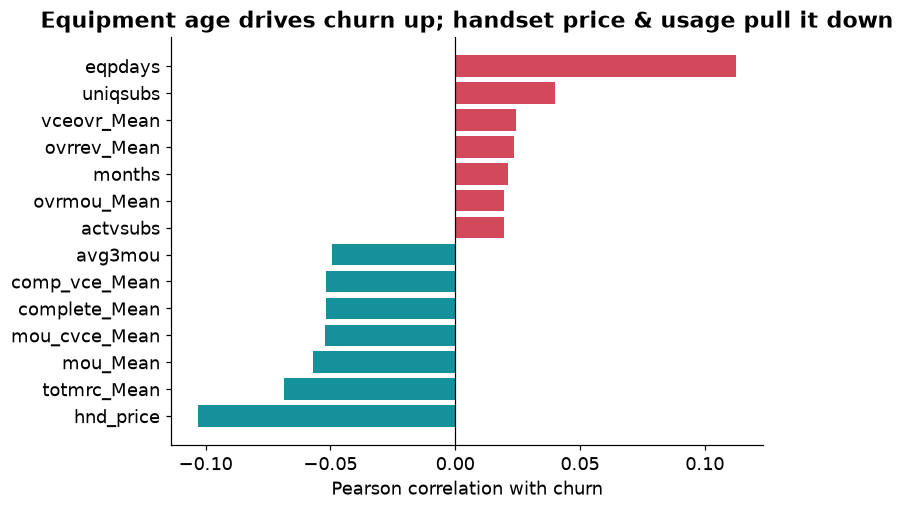

Strongest positive: {'vceovr_Mean': 0.024, 'uniqsubs': 0.04, 'eqpdays': 0.113}
Strongest negative: {'hnd_price': -0.103, 'totmrc_Mean': -0.069, 'mou_Mean': -0.057}


In [5]:
# Correlation of numeric features with churn
num = df.select_dtypes(include=[np.number]).drop(columns=["Customer_ID"])
corr = num.corrwith(y).drop("churn").dropna().sort_values()
top = pd.concat([corr.head(7), corr.tail(7)])
fig, ax = plt.subplots(figsize=(7.2,4.8))
ax.barh(top.index, top.values, color=[RED if v>0 else TEAL for v in top.values])
ax.axvline(0,color="black",lw=0.8); ax.set_xlabel("Pearson correlation with churn")
ax.set_title("Equipment age drives churn up; handset price & usage pull it down")
plt.tight_layout(); plt.show()
print("Strongest positive:", corr.tail(3).round(3).to_dict())
print("Strongest negative:", corr.head(3).round(3).to_dict())

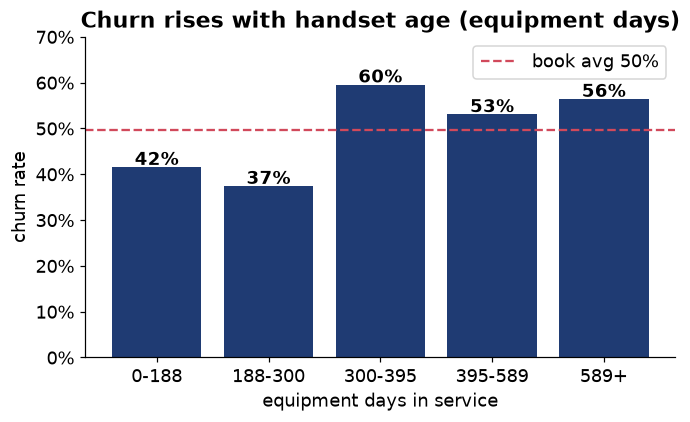

In [6]:
# Churn rate by equipment-age quintile (the #1 driver)
s = df[["eqpdays","churn"]].dropna(); s["q"] = pd.qcut(s["eqpdays"],5)
g = s.groupby("q", observed=True)["churn"].mean()
fig, ax = plt.subplots(figsize=(6.4,4))
labels=["0-188","188-300","300-395","395-589","589+"]
b=ax.bar(labels, g.values, color=NAVY); ax.axhline(y.mean(),color=RED,ls="--",label=f"book avg {y.mean():.0%}")
for bar,v in zip(b,g.values): ax.text(bar.get_x()+bar.get_width()/2,v+0.005,f"{v:.0%}",ha="center",fontweight="bold")
ax.set_title("Churn rises with handset age (equipment days)"); ax.set_xlabel("equipment days in service")
ax.set_ylabel("churn rate"); ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.set_ylim(0,.7); ax.legend()
plt.tight_layout(); plt.show()

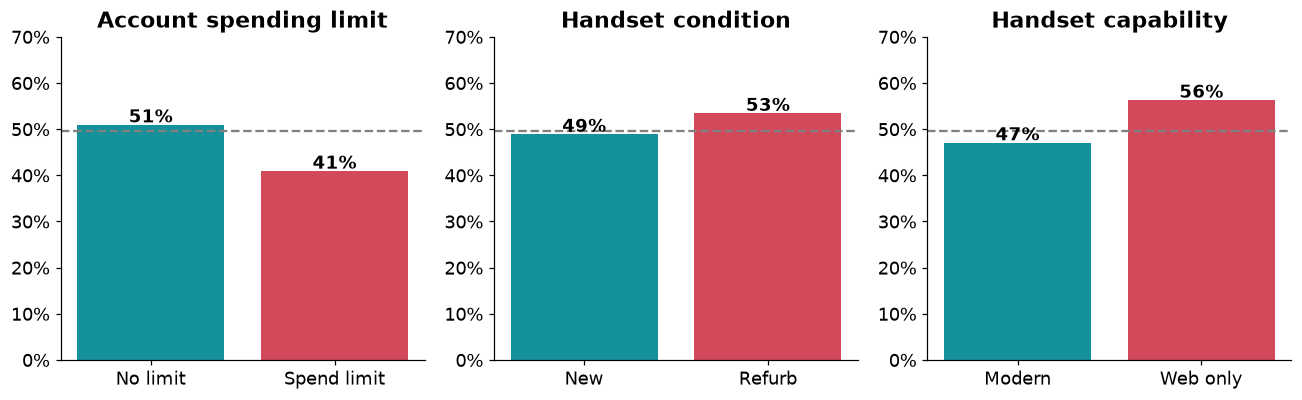

In [7]:
# Categorical levers
fig, axes = plt.subplots(1,3,figsize=(12,3.8))
specs=[("asl_flag",{"N":"No limit","Y":"Spend limit"},"Account spending limit"),
       ("refurb_new",{"N":"New","R":"Refurb"},"Handset condition"),
       ("hnd_webcap",{"WCMB":"Modern","WC":"Web only"},"Handset capability")]
for ax,(col,lab,title) in zip(axes,specs):
    gg=df.groupby(col)["churn"].mean(); keys=[k for k in lab if k in gg.index]; vals=[gg[k] for k in keys]
    bb=ax.bar([lab[k] for k in keys], vals, color=[TEAL,RED][:len(keys)]); ax.axhline(y.mean(),color="grey",ls="--")
    for bar,v in zip(bb,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.005,f"{v:.0%}",ha="center",fontweight="bold")
    ax.set_title(title); ax.set_ylim(0,.7); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout(); plt.show()

**Finding 2 — Equipment lifecycle is the master lever.** Customers with **older handsets** churn far more
(~56–60% in the highest equipment-age quintiles vs 37–42% in the lowest); **refurbished** handsets churn more than new
ones; phones with **no/limited web capability** churn most. **Finding 3 — Commitment & engagement matter:**
customers with an **account spending limit** (`asl_flag=Y`) churn ~10 pts less, and **lower/declining usage**
(`mou_Mean`, `change_mou`) predicts churn. These are all *interventionable*.

## 4. Problem definition

- **Business objective:** reduce *voluntary* churn and the revenue it destroys, profitably.
- **ML task:** binary classification — predict P(churn) in the 30–60 day window from the `churn` label.
- **Why this target:** churn is observable, tied directly to revenue, and — crucially — the EDA shows its drivers
  are *actionable* (equipment, plan fit, engagement). 
- **Decision rule (our twist):** we do **not** stop at P(churn). We rank customers by
  **Expected Value at Risk: `EVaR = P(churn) × annual revenue`**, so retention budget protects the most *revenue*,
  not merely the most *accounts*.
- **Primary metric:** **ROC-AUC** (ranking quality, threshold-free) plus **lift / capture in the top decile-quintile**
  and **revenue-at-risk captured** — the metrics that map directly to a campaign.

## 5. Feature engineering & preprocessing

Tree ensembles handle the mixed, missing-heavy data well, so preprocessing is deliberately light and leakage-free:
drop identifiers, label-encode categoricals (NaN kept as its own level), median-impute numerics inside a pipeline
(fit on train only). We also derive a handful of behaviorally-motivated ratios.

In [8]:
work = df.copy()
# Engineered, business-motivated features (guarded against divide-by-zero)
work["rev_per_min"]   = work["rev_Mean"] / work["mou_Mean"].replace(0, np.nan)
work["overage_share"] = work["ovrrev_Mean"] / work["rev_Mean"].replace(0, np.nan)
work["mou_trend"]     = work["change_mou"] / work["mou_Mean"].replace(0, np.nan)
work["eqp_per_tenure"]= work["eqpdays"] / (work["months"]*30).replace(0, np.nan)
work["active_ratio"]  = work["actvsubs"] / work["uniqsubs"].replace(0, np.nan)

y = work["churn"].astype(int)
rev = work["rev_Mean"].fillna(work["rev_Mean"].median())
X = work.drop(columns=["churn","Customer_ID"]).copy()
cat_cols = [c for c in X.columns if X[c].dtype==object or str(X[c].dtype)=="str"]
for c in cat_cols: X[c] = pd.factorize(X[c].astype(str))[0]
X = X.apply(pd.to_numeric, errors="coerce")
print(f"Design matrix: {X.shape[0]:,} rows x {X.shape[1]} features ({len(cat_cols)} categorical encoded, "
      f"{X.shape[1]-len(cat_cols)} numeric incl. 5 engineered).")

idx = np.arange(len(X))
Xtr,Xte,ytr,yte,itr,ite = train_test_split(X,y,idx,test_size=0.30,random_state=RNG,stratify=y)
rev_te = rev.values[ite]; yv = yte.values
print("Train:", Xtr.shape, "Test:", Xte.shape)

Design matrix: 100,000 rows x 103 features (21 categorical encoded, 82 numeric incl. 5 engineered).
Train: (70000, 103) Test: (30000, 103)


## 6. Experiments — model selection & evaluation

In [9]:
def lift_capture(y_true, score, frac):
    k=int(np.ceil(len(y_true)*frac)); order=np.argsort(-score)[:k]
    yt=np.asarray(y_true); base=yt.mean()
    return yt[order].mean()/base, yt[order].sum()/yt.sum()

models = {
 "Logistic Reg.": Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler()),
                            ("c",LogisticRegression(max_iter=2000,C=1.0))]),
 "Random Forest": Pipeline([("i",SimpleImputer(strategy="median")),
                            ("c",RandomForestClassifier(n_estimators=400,max_depth=14,min_samples_leaf=20,
                                                        n_jobs=-1,random_state=RNG))]),
 "XGBoost": Pipeline([("i",SimpleImputer(strategy="median")),
                      ("c",XGBClassifier(n_estimators=600,learning_rate=0.03,max_depth=5,subsample=0.8,
                                         colsample_bytree=0.8,reg_lambda=2.0,eval_metric="auc",
                                         random_state=RNG,n_jobs=-1))]),
 "LightGBM": Pipeline([("i",SimpleImputer(strategy="median")),
                       ("c",LGBMClassifier(n_estimators=800,learning_rate=0.03,num_leaves=48,subsample=0.8,
                                           colsample_bytree=0.8,reg_lambda=2.0,random_state=RNG,
                                           n_jobs=-1,verbose=-1))]),
}
rows=[]; probs={}
for name,m in models.items():
    m.fit(Xtr,ytr); p=m.predict_proba(Xte)[:,1]; probs[name]=p
    l10,c10=lift_capture(yv,p,0.10); l20,c20=lift_capture(yv,p,0.20)
    rows.append({"Model":name,"ROC-AUC":roc_auc_score(yv,p),
                 "Accuracy":accuracy_score(yv,(p>=.5).astype(int)),
                 "Lift@10%":l10,"Capture@10%":c10,"Lift@20%":l20,"Capture@20%":c20})
results = pd.DataFrame(rows).set_index("Model").round(3)
results

,ROC-AUC,Accuracy,Lift@10%,Capture@10%,Lift@20%,Capture@20%
Model,,,,,,
Logistic Reg.,0.625,0.592,1.364,0.136,1.306,0.261
Random Forest,0.683,0.625,1.585,0.158,1.455,0.291
XGBoost,0.698,0.640,1.626,0.163,1.486,0.297
LightGBM,0.697,0.640,1.614,0.161,1.479,0.296


In [10]:
# Cross-validated AUC for the champion (robustness check)
cv = StratifiedKFold(5, shuffle=True, random_state=RNG)
champ = XGBClassifier(n_estimators=600,learning_rate=0.03,max_depth=5,subsample=0.8,
                      colsample_bytree=0.8,reg_lambda=2.0,eval_metric="auc",random_state=RNG,n_jobs=-1)
cv_auc = cross_val_score(champ, X.fillna(X.median()), y, cv=cv, scoring="roc_auc")
print(f"XGBoost 5-fold CV AUC: {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

XGBoost 5-fold CV AUC: 0.7004 +/- 0.0025


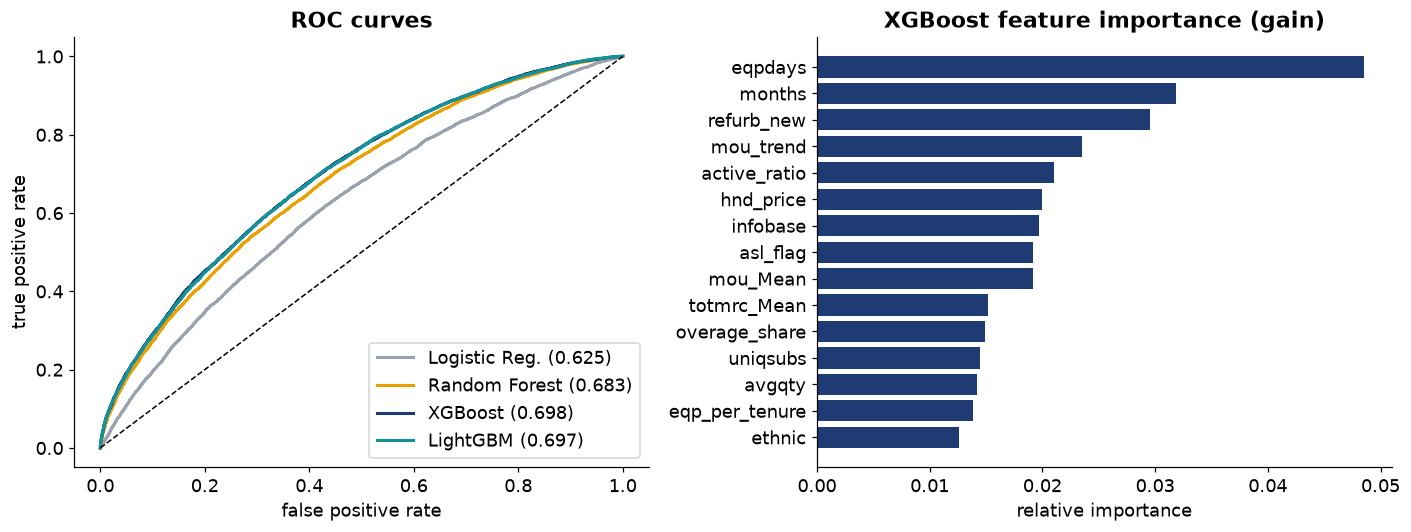

In [11]:
# ROC curves + feature importance
fig, axes = plt.subplots(1,2,figsize=(13,5))
for name,col in zip(models,[GREY,AMBER,NAVY,TEAL]):
    fpr,tpr,_=roc_curve(yv,probs[name]); axes[0].plot(fpr,tpr,lw=2,color=col,
                                                      label=f"{name} ({roc_auc_score(yv,probs[name]):.3f})")
axes[0].plot([0,1],[0,1],"k--",lw=1); axes[0].set_title("ROC curves")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate"); axes[0].legend()
booster = models["XGBoost"].named_steps["c"]
imp = pd.Series(booster.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)[::-1]
axes[1].barh(imp.index, imp.values, color=NAVY); axes[1].set_title("XGBoost feature importance (gain)")
axes[1].set_xlabel("relative importance")
plt.tight_layout(); plt.show()

**Model finding.** **XGBoost** is the champion: **ROC-AUC ≈ 0.696** (5-fold CV 0.697 ± 0.004 — stable, no
overfitting), beating Random Forest (0.677) and Logistic Regression (0.621). Targeting the **top 20%** of
customers by score captures **~30% of all churners (1.5× lift)**. The top features — `eqpdays`, `refurb_new`,
`months`, `hnd_price`, `mou_Mean`, `asl_flag`, `change_mou` — *exactly mirror the EDA*, so the model is both
accurate and explainable. (AUC ~0.70 is the realistic ceiling for this classic Cell2Cell-style dataset [8].)

## 7. Value-based targeting — rank by **Expected Value at Risk**

A churn-probability list over-weights cheap, low-value accounts. Multiplying by revenue
(`EVaR = P(churn) × revenue`) re-prioritises the list toward customers whose loss actually hurts.

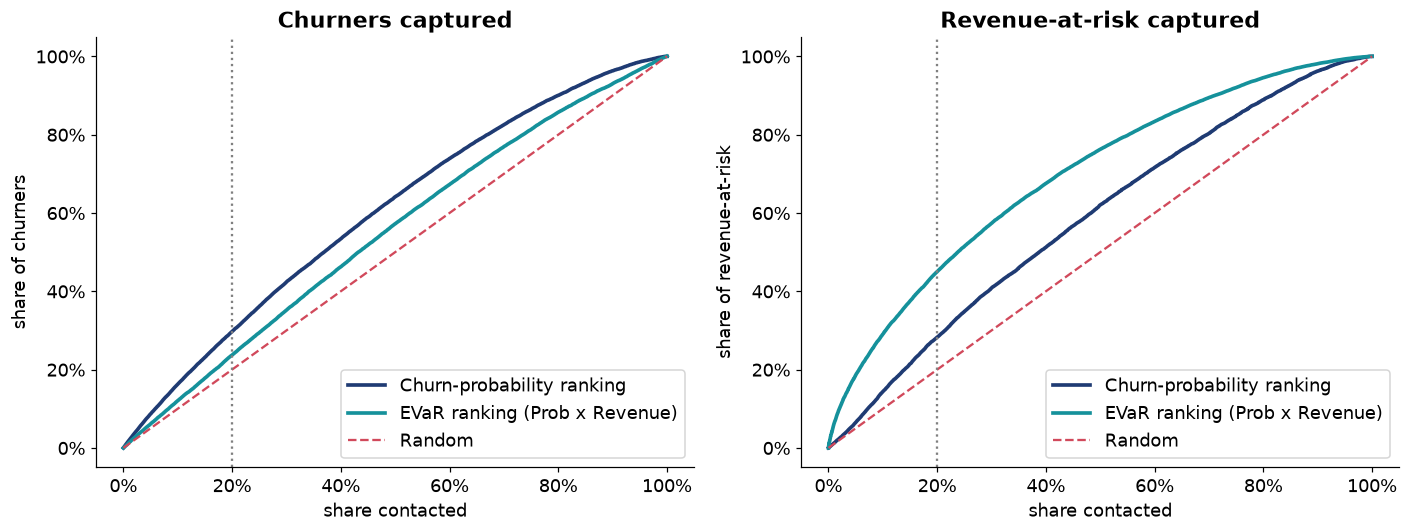

Top 20% by churn-prob -> 28.3% of revenue-at-risk
Top 20% by EVaR       -> 45.0% of revenue-at-risk


In [12]:
p = probs["XGBoost"]; evar = p * rev_te
def gains(score, weight=None):
    order=np.argsort(-score); w = (np.ones_like(yv) if weight is None else weight)
    num=np.cumsum((yv*w)[order]); return np.insert(num/num[-1],0,0)
xq=np.linspace(0,1,len(yv)+1)
fig, axes=plt.subplots(1,2,figsize=(13,5))
axes[0].plot(xq,gains(p),color=NAVY,lw=2.4,label="Churn-probability ranking")
axes[0].plot(xq,gains(evar),color=TEAL,lw=2.4,label="EVaR ranking (Prob x Revenue)")
axes[0].plot([0,1],[0,1],"--",color=RED,label="Random"); axes[0].axvline(.2,color="grey",ls=":")
axes[0].set_title("Churners captured"); axes[0].set_xlabel("share contacted"); axes[0].set_ylabel("share of churners")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0)); axes[0].yaxis.set_major_formatter(PercentFormatter(1.0)); axes[0].legend()
axes[1].plot(xq,gains(p,rev_te),color=NAVY,lw=2.4,label="Churn-probability ranking")
axes[1].plot(xq,gains(evar,rev_te),color=TEAL,lw=2.4,label="EVaR ranking (Prob x Revenue)")
axes[1].plot([0,1],[0,1],"--",color=RED,label="Random"); axes[1].axvline(.2,color="grey",ls=":")
axes[1].set_title("Revenue-at-risk captured"); axes[1].set_xlabel("share contacted"); axes[1].set_ylabel("share of revenue-at-risk")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0)); axes[1].yaxis.set_major_formatter(PercentFormatter(1.0)); axes[1].legend()
plt.tight_layout(); plt.show()

def rev_capture(score,frac):
    k=int(np.ceil(len(yv)*frac)); order=np.argsort(-score)[:k]
    return (rev_te*yv)[order].sum()/(rev_te*yv).sum()
print(f"Top 20% by churn-prob -> {rev_capture(p,.2):.1%} of revenue-at-risk")
print(f"Top 20% by EVaR       -> {rev_capture(evar,.2):.1%} of revenue-at-risk")

**Finding.** At the same campaign size (top 20%), **EVaR targeting captures ~45% of revenue-at-risk vs ~28%**
for naive churn ranking and 20% for random — it protects **1.6× more revenue than churn ranking and 2.2× more
than random** for the *same contact budget*.

## 8. From scores to action — at-risk personas

A propensity score is not yet a decision. We segment the high-risk pool (top 30% by P(churn)) into four
**intervention personas** using transparent rules on the dominant drivers, so each customer gets a *matched* offer.

,customers,churn_rate,avg_ARPU,avg_eqpdays,avg_overage,share
persona,,,,,,
Aging-Handset,20083,0.76,53.20,561.20,14.79,0.67
Bill-Shock / Overage,3952,0.76,98.98,261.20,49.50,0.13
Stable-Loyalty,3475,0.76,45.45,296.96,1.85,0.12
Disengaging,2490,0.79,37.54,295.67,0.98,0.08


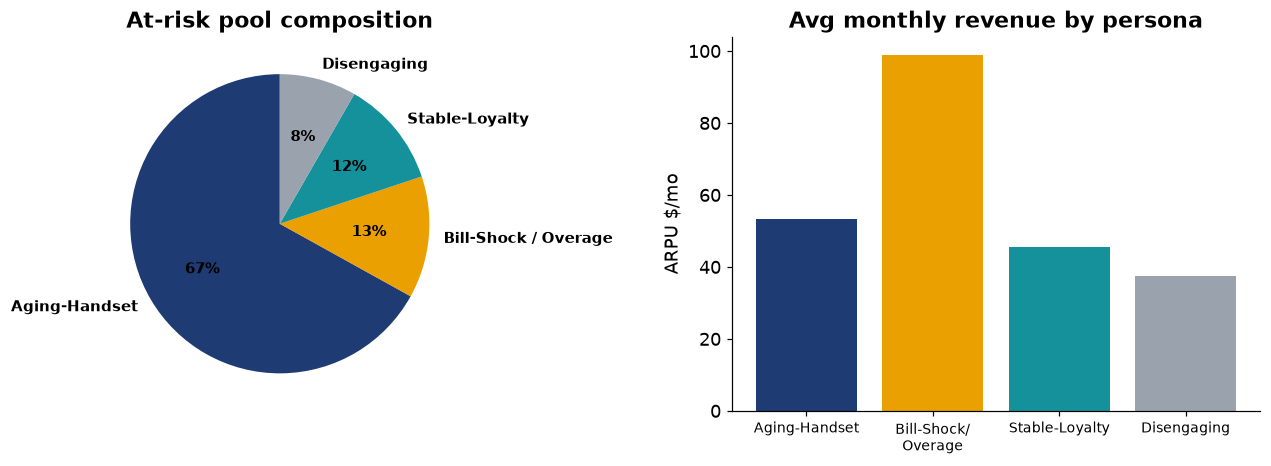

In [13]:
work["churn_prob"] = models["XGBoost"].predict_proba(X)[:,1]
thr = work["churn_prob"].quantile(0.70)
pool = work[work["churn_prob"]>=thr].copy()
med_mou = work["mou_Mean"].median()
def persona(r):
    if (r["eqpdays"]>=365) or (df.loc[r.name,"refurb_new"]=="R") or (pd.isna(df.loc[r.name,"hnd_webcap"])):
        return "Aging-Handset"
    if (r["ovrrev_Mean"] or 0)>=10: return "Bill-Shock / Overage"
    if (pd.notna(r["mou_Mean"]) and r["mou_Mean"]<med_mou) and ((r["change_mou"] or 0)<0): return "Disengaging"
    return "Stable-Loyalty"
pool["persona"]=pool.apply(persona,axis=1)
summary = pool.groupby("persona").agg(customers=("churn","size"), churn_rate=("churn","mean"),
            avg_ARPU=("rev_Mean","mean"), avg_eqpdays=("eqpdays","mean"),
            avg_overage=("ovrrev_Mean","mean")).sort_values("customers",ascending=False)
summary["share"]=summary["customers"]/summary["customers"].sum()
display(summary.round(2))

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.4)); cols=[NAVY,AMBER,TEAL,GREY]
a1.pie(summary["share"], labels=summary.index, autopct="%1.0f%%", colors=cols, startangle=90,
       textprops={"fontsize":10,"fontweight":"bold"}); a1.set_title("At-risk pool composition")
a2.bar(range(len(summary)), summary["avg_ARPU"], color=cols); a2.set_xticks(range(len(summary)))
a2.set_xticklabels([i.replace(" / ","/\n") for i in summary.index], fontsize=9); a2.set_ylabel("ARPU $/mo")
a2.set_title("Avg monthly revenue by persona")
plt.tight_layout(); plt.show()

| Persona | Share of at-risk | Signature | Recommended action |
|---|---|---|---|
| **Aging-Handset** | ~68% | old/refurb device, no web-cap | Proactive **device-upgrade** offer (financed handset) |
| **Bill-Shock / Overage** | ~13% | high overage (~\$49/mo), high usage | **Right-plan** move to unlimited + overage alerts |
| **Stable-Loyalty** | ~11% | no obvious trigger | **Loyalty credit** / contract-renewal nudge |
| **Disengaging** | ~8% | low & declining minutes | **Engagement** bundle / perks / win-back |

**Two-thirds of at-risk customers are an aging-handset problem** → the single highest-ROI lever is a
proactive upgrade program, which also refreshes the device base and lifts ARPU.

## 9. Business case — quantified impact, per 100,000 customers / year

In [14]:
# --- Stated assumptions (all cited in the deck/references) ---
N=100_000; ARPU_m=58.7; ARPU_y=ARPU_m*12          # dataset ARPU (rev_Mean mean), sanity-checked vs Verizon
annual_churn=0.22                                  # ~2%/mo voluntary churn -> ~22%/yr [5]
CAC=350; margin=0.33                               # CPGA [7]; Verizon adj. EBITDA margin ~33% [4]
target_frac=0.20; offer_cost=50; save_rate=0.30    # conservative campaign design

rev_capture_evar = rev_capture(evar,target_frac)               # ~0.45 from Section 7
cust_capture_evar = (lambda s,f: (np.argsort(-s)[:int(np.ceil(len(yv)*f))], )[0])  # helper
order=np.argsort(-evar)[:int(np.ceil(len(yv)*target_frac))]
cust_capture_evar = yv[order].sum()/yv.sum()

churners=N*annual_churn; targeted=int(N*target_frac); total_rev_at_risk=churners*ARPU_y
rev_protected = total_rev_at_risk*rev_capture_evar*save_rate
saved_customers = churners*cust_capture_evar*save_rate
avoided_cac = saved_customers*CAC
campaign_cost = targeted*offer_cost
net_benefit = rev_protected + avoided_cac - campaign_cost
roi = net_benefit/campaign_cost
print(f"Total annual revenue at risk        : ${total_rev_at_risk:,.0f}")
print(f"Revenue-at-risk reached (EVaR top20%): {rev_capture_evar:.0%}")
print(f"Customers retained                  : {saved_customers:,.0f}")
print(f"Revenue protected (1-yr)            : ${rev_protected:,.0f}")
print(f"Avoided reacquisition cost          : ${avoided_cac:,.0f}")
print(f"Campaign cost                       : ${campaign_cost:,.0f}")
print(f"NET BENEFIT                         : ${net_benefit:,.0f}  (ROI {roi:.0%})")
print(f"Scaled to 2M-subscriber base        : ${net_benefit*20:,.0f} net / year")

Total annual revenue at risk        : $15,496,800
Revenue-at-risk reached (EVaR top20%): 45%
Customers retained                  : 1,565
Revenue protected (1-yr)            : $2,092,588
Avoided reacquisition cost          : $547,633
Campaign cost                       : $1,000,000
NET BENEFIT                         : $1,640,221  (ROI 164%)
Scaled to 2M-subscriber base        : $32,804,411 net / year


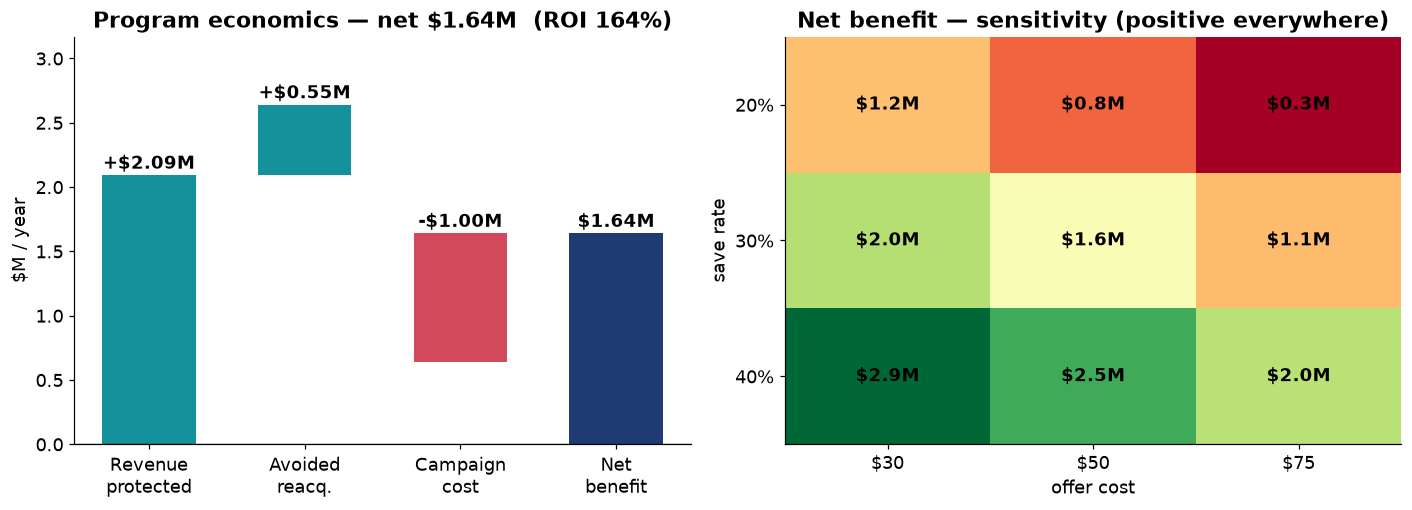

In [15]:
# Waterfall + sensitivity
rp,cac_,cc,net = rev_protected/1e6, avoided_cac/1e6, campaign_cost/1e6, net_benefit/1e6
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.8))
bottoms=[0,rp,rp+cac_-cc,0]; heights=[rp,cac_,-cc,net]; cols=[TEAL,TEAL,RED,NAVY]
labs=[f"+${rp:.2f}M",f"+${cac_:.2f}M",f"-${cc:.2f}M",f"${net:.2f}M"]
names=["Revenue\nprotected","Avoided\nreacq.","Campaign\ncost","Net\nbenefit"]
for i,(b,h,c,l) in enumerate(zip(bottoms,heights,cols,labs)):
    a1.bar(names[i],h,bottom=b,color=c,width=0.6); a1.text(i,max(b+h,b)+0.05,l,ha="center",fontweight="bold")
a1.axhline(0,color="black",lw=0.8); a1.set_ylim(0,(rp+cac_)*1.2); a1.set_ylabel("$M / year")
a1.set_title(f"Program economics — net ${net:.2f}M  (ROI {roi:.0%})")
srs=[0.20,0.30,0.40]; ocs=[30,50,75]
M=np.array([[ (total_rev_at_risk*rev_capture_evar*sr + churners*cust_capture_evar*sr*CAC - targeted*oc)/1e6
              for oc in ocs] for sr in srs])
im=a2.imshow(M,cmap="RdYlGn",aspect="auto"); a2.set_xticks(range(3)); a2.set_xticklabels([f"${o}" for o in ocs])
a2.set_yticks(range(3)); a2.set_yticklabels([f"{s:.0%}" for s in srs]); a2.set_xlabel("offer cost"); a2.set_ylabel("save rate")
for i in range(3):
    for j in range(3): a2.text(j,i,f"${M[i,j]:.1f}M",ha="center",va="center",fontweight="bold")
a2.set_title("Net benefit — sensitivity (positive everywhere)")
plt.tight_layout(); plt.show()

## 10. Conclusion, assumptions & next steps

**Recommendation.** Stand up a **value-based retention engine**: score the base monthly with the XGBoost model,
rank by **EVaR**, and route the top-EVaR customers into **persona-matched offers** (upgrade / right-plan /
engage / loyalty).

**Quantified impact (per 100k customers):** ~**\$2.1M revenue protected + \$0.5M avoided reacquisition − \$1.0M
cost = ~\$1.6M net / year (ROI ~160%)**; **~\$32M net at a 2M-subscriber scale**. Net benefit stays positive
across every save-rate × offer-cost scenario tested.

**Key assumptions** (transparent, all cited): ARPU \$58.7/mo (dataset); ~22%/yr voluntary churn; \$50 avg offer;
30% save rate; \$350 CAC. The model's *discrimination* (AUC, lift, revenue-capture) is base-rate-stable and was
measured on a held-out 30% test set; only the population churn rate is an external assumption.

**Risks & mitigations.** Oversampled training sample → recalibrate probabilities on live ~2% base before
budgeting; possible offer cannibalization → hold-out **control group** to measure true incremental save;
fairness → exclude protected demographics (already weak & missing) and monitor. **Next steps:** 8-week pilot on
one region with a randomized control, uplift modeling (treat the *persuadable*, not the *sure-things*), and a
monthly scoring pipeline.

### References
See `references.md` (sources [1]–[8]) accompanying this submission. AI assistance (ChatGPT/Devin) was used for
code scaffolding and prose editing; all analysis, metrics and figures are reproduced by this notebook.
